# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game data for premier league forwards for
the current season, splitting into train/test sets, creating datasets and
dataloaders from them, training a `FootballLSTM` instance, and evaluating
it.

In [1]:
import sys
import os
from understatapi import UnderstatClient
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from matplotlib import pyplot as plt

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset
from football_lstm import FootballLSTM
from utils import hyperparam_tuning

In [2]:
# Create understat connection
understat = UnderstatClient()

In [3]:
# Choose what stats to forecast, and how many past games to use to predict
# the current one
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
games_per_block = 10

In [4]:
# Get forward stats for all seasons in top 5 leagues
# leagues = ["EPL", "La_Liga", "Bundesliga", "Serie_A", "Ligue_1"]
leagues = ["EPL"]
seasons = [2021,2022,2023,2024,2025]

# save dataset to csv to avoid pulls

f_stats = get_position_players_stats_df(understat, ['F'], games_per_block, stats, leagues=leagues, seasons=seasons)
f_stats.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
501       2014-11-09      0.242588   0.383968        0.242588   0.193251   
          2015-02-21      0.219245   0.342837        0.000000   0.125037   
          2016-03-02      0.676692   0.674658        0.338346   0.052056   
          2017-01-22      0.376569   0.369227        0.376569   0.143245   
          2017-05-07      0.337711   0.358315        0.000000   0.016379   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
501       2014-11-09           1.819407        0.725172          0.254158  
          2015-02-21           1.425091        0.554091          0.148639  
          2016-03-02           0.676692        1.004714          0.481958  
          2017-01-22           1.317992        0.546316          0.131956  
          2017-05-07           0.506567        0.299221          0.054215

In [5]:
# Train/test split
train_len = int(len(f_stats) * 0.8)
train_df = f_stats.iloc[:train_len]
test_df = f_stats.iloc[train_len:]

In [6]:
train_df.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
501       2014-11-09      0.242588   0.383968        0.242588   0.193251   
          2015-02-21      0.219245   0.342837        0.000000   0.125037   
          2016-03-02      0.676692   0.674658        0.338346   0.052056   
          2017-01-22      0.376569   0.369227        0.376569   0.143245   
          2017-05-07      0.337711   0.358315        0.000000   0.016379   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
501       2014-11-09           1.819407        0.725172          0.254158  
          2015-02-21           1.425091        0.554091          0.148639  
          2016-03-02           0.676692        1.004714          0.481958  
          2017-01-22           1.317992        0.546316          0.131956  
          2017-05-07           0.506567        0.299221          0.054215

In [7]:
# Create datasets
blocks_per_input = 5

train_dataset = CustomFootballDataset(train_df, blocks_per_input, multiple_players=True)
test_dataset = CustomFootballDataset(test_df, blocks_per_input, multiple_players=True)

In [8]:
len(train_dataset)

2401

In [9]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [10]:
# Tuning params
params = {
    "learning_rates": [0.1, 0.001, 0.0001, 0.00001],
    "epochs": [10, 30, 50],
    "h_sizes": [16, 32, 64], # 128
    "layers": [1, 2, 4],
    "dropouts": [0.3, 0.5, 0.7]
}

opt_hyper_params = hyperparam_tuning(params, stats_df=f_stats, train_dataloader=train_dataloader, 
                                             test_dataloader=test_dataloader)

print(f"""
      Best Hyperparameter setup \n
      - learning rate: {opt_hyper_params['learning_rate']} 
      - number of epochs: {opt_hyper_params['epoch']}.
      - number of layers: {opt_hyper_params['layers']}.
      - hidden size: {opt_hyper_params['hidden_size']}.
      - dropout: {opt_hyper_params['dropout']}.
      """)


      Best Hyperparameter setup 

      - learning rate: 0.001 
      - number of epochs: 50.
      - number of layers: 1.
      - hidden size: 16.
      - dropout: 0.
      


In [11]:
# Tuned setup to MSE Loss and Adam
loss_fn = nn.MSELoss()
model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=opt_hyper_params['hidden_size'], 
                     num_layers=opt_hyper_params['hidden_size'], dropout=opt_hyper_params['dropout'])
optimizer = torch.optim.Adam(model.parameters(), lr=opt_hyper_params['learning_rate'])
num_epochs = opt_hyper_params['epoch']

# Train model
train_losses, test_losses = model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs
)

In [12]:
# Evaluate test performance

rmse, mae = model.eval_model(test_dataloader)
print(f"Test RMSE: {rmse}")
print(f"Test MAE: {mae}")

Test RMSE: 0.2989979386329651
Test MAE: 0.23871564865112305


RMSE: 0.3717356026172638
MAE: 0.3371436297893524
goals_per_90 RMSE: 0.5698806047439575
goals_per_90 MAE: 0.5167164206504822
xG_per_90 RMSE: 0.5951918959617615
xG_per_90 MAE: 0.578986406326294
assists_per_90 RMSE: 0.14695556461811066
assists_per_90 MAE: 0.11678767204284668
xA_per_90 RMSE: 0.07457878440618515
xA_per_90 MAE: 0.06600960344076157
key_passes_per_90 RMSE: 0.7587471008300781
key_passes_per_90 MAE: 0.6649608612060547
xGChain_per_90 RMSE: 0.27585628628730774
xGChain_per_90 MAE: 0.24271756410598755
xGBuildup_per_90 RMSE: 0.1809392273426056
xGBuildup_per_90 MAE: 0.17382684350013733


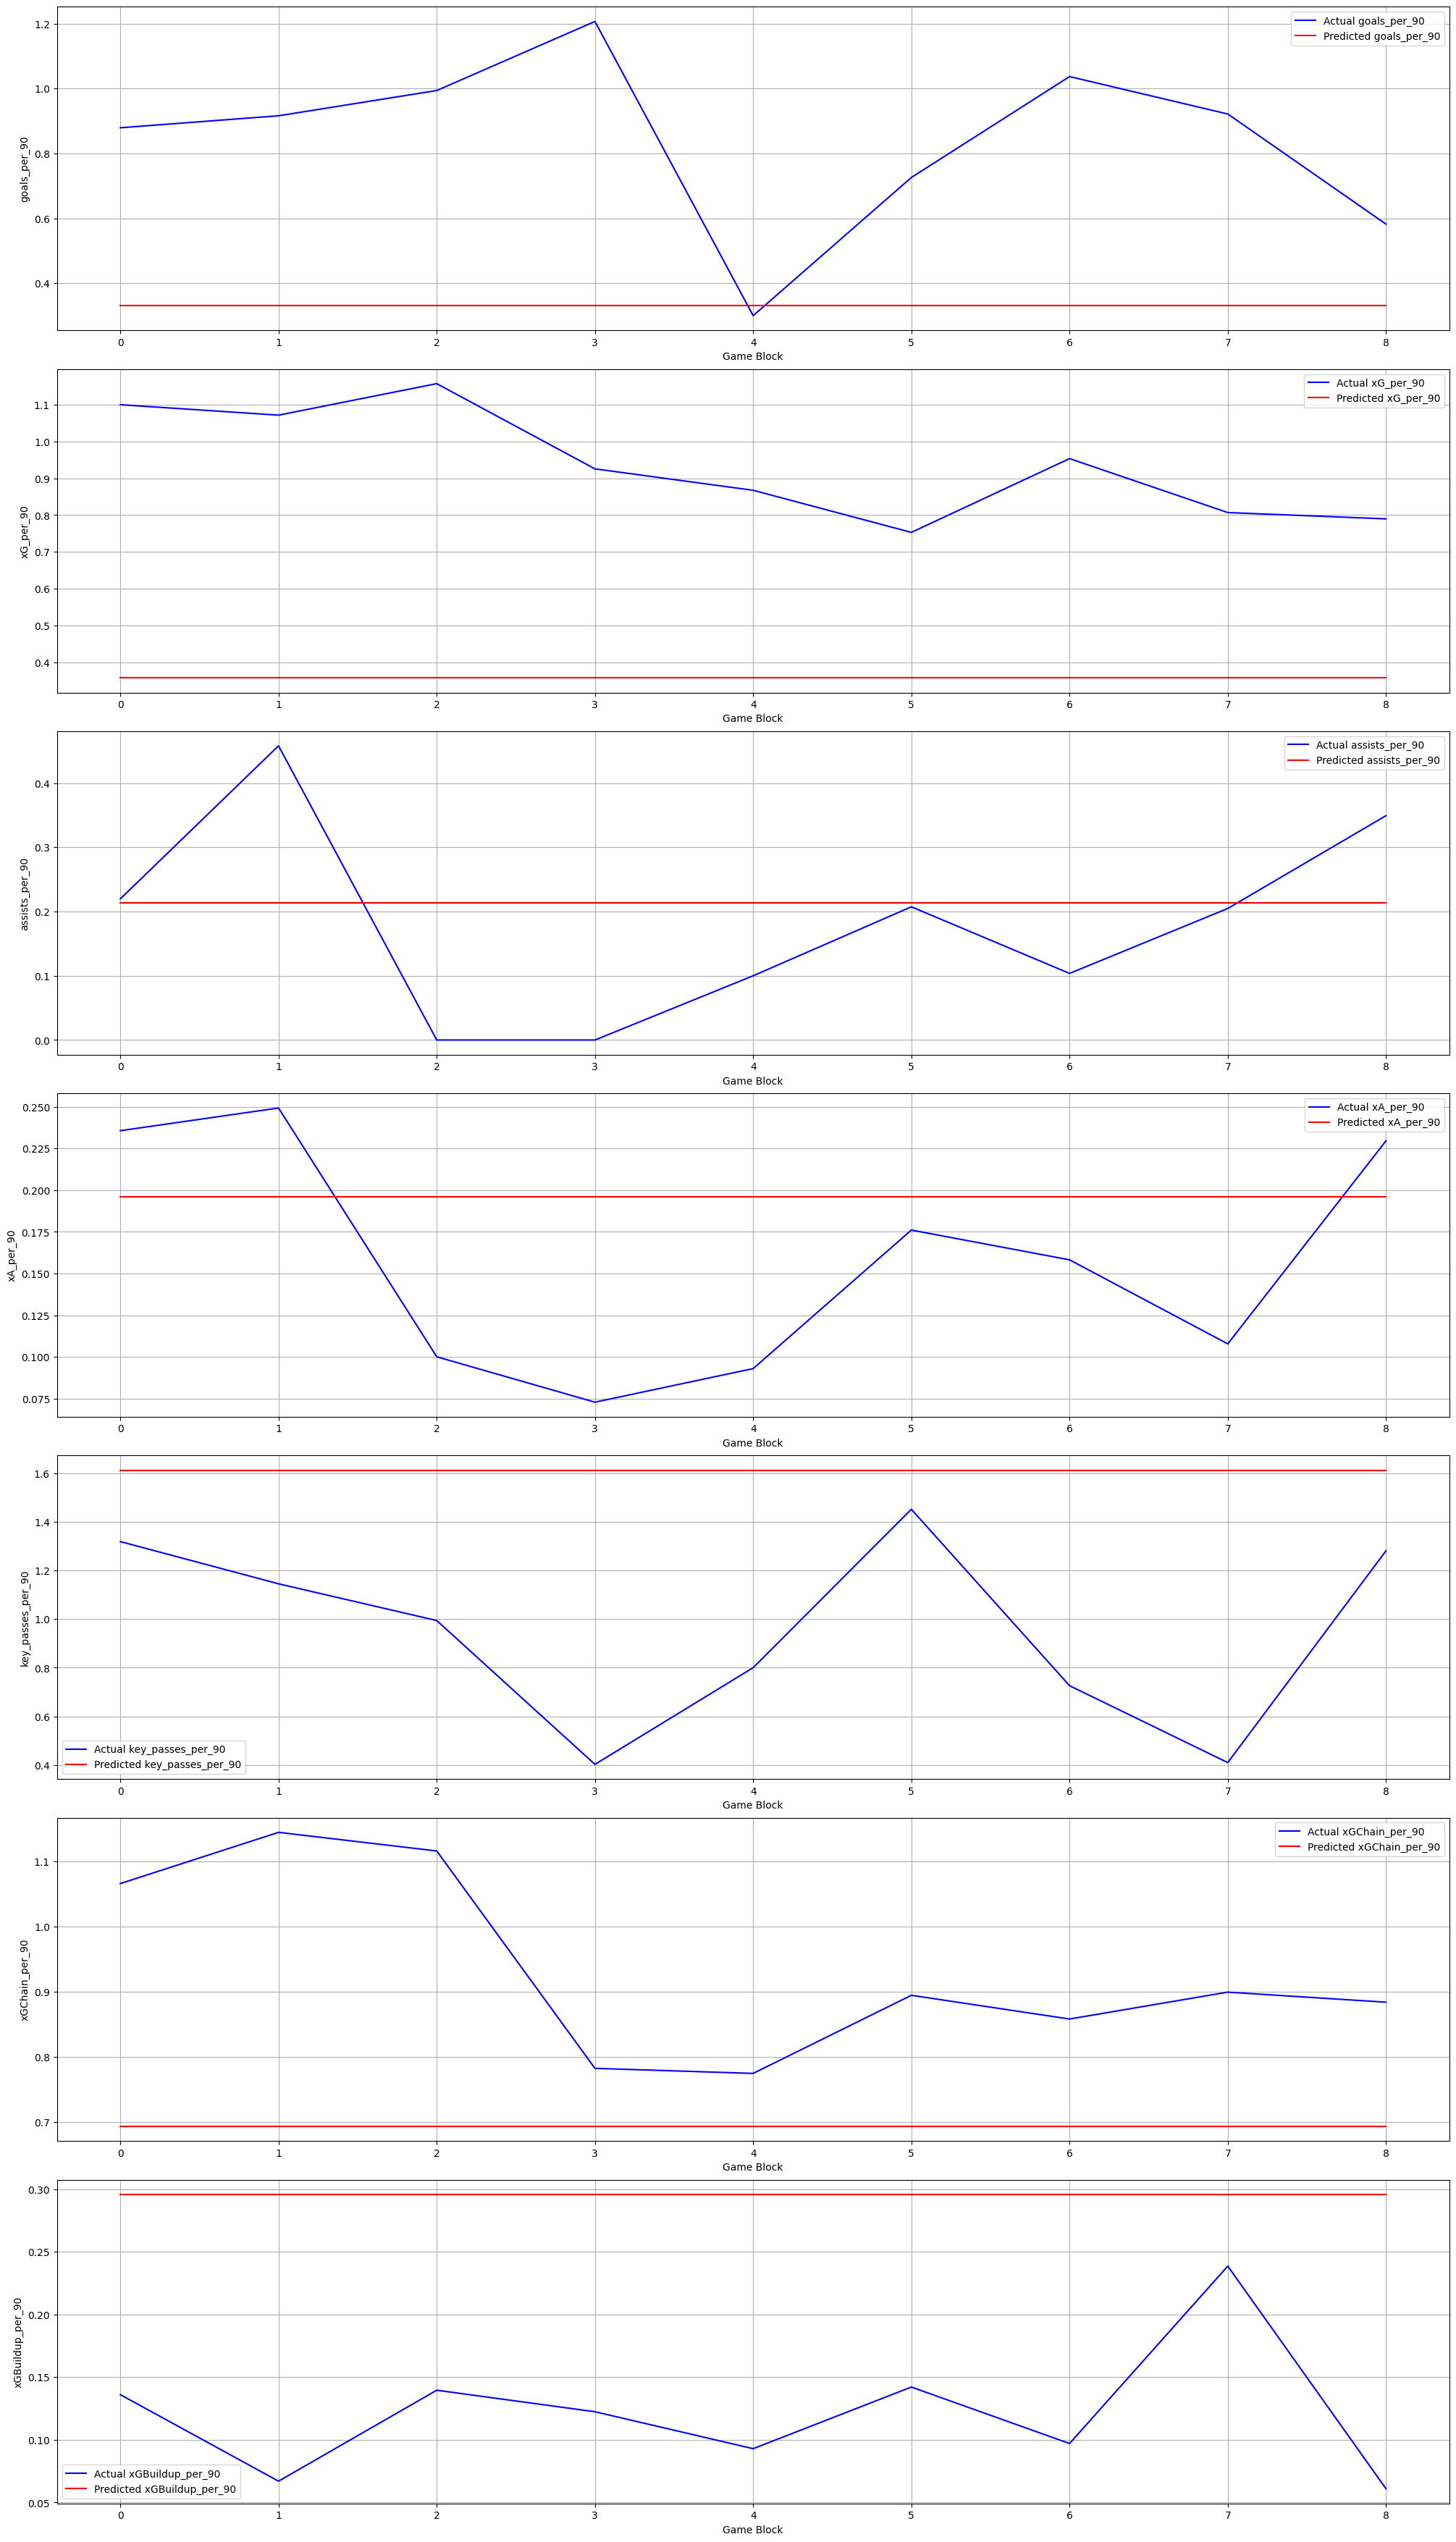

In [13]:
# See how model does on forecasting a specific player--Erling Haaland

haaland_df = f_stats.loc["8260"]

model.eval_model_on_player(haaland_df)